<a href="https://colab.research.google.com/github/AG98190/XRayPneumoniaRepository/blob/main/XRayPneumonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
path


'/kaggle/input/chest-xray-pneumonia'

In [ ]:
import os
import torch
import torchvision
from torchvision import transforms,models
from torch import nn,optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
base_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"


categories = ['NORMAL','PNEUMONIA']
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
class ChestXRayDataset(Dataset):
  def __init__(self,root_dir,categories,transform=None):
    self.images = []
    self.labels = []
    self.transform = transform
    for(index,label) in enumerate(categories):
      new_path = os.path.join(root_dir,label)
      for image_name in os.listdir(new_path):
        image_path = os.path.join(new_path,image_name)
        try:
          img = Image.open(image_path)
          self.images.append(image_path)
          self.labels.append(index)
        except:
          continue
  def __len__(self):
    return len(self.images)
  def __getitem__(self,index):
    image_path = self.images[index]
    label = self.labels[index]
    image = Image.open(image_path).convert('RGB')
    if self.transform:
      image = self.transform(image)
    return image,label


In [ ]:
train_dataset = ChestXRayDataset(base_path,categories,transform)
test_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"
test_dataset = ChestXRayDataset(test_path,categories,transform)
val_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
val_dataset = ChestXRayDataset(val_path,categories,transform)

In [ ]:
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=True,num_workers=2)
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,num_workers=2)
test_loader = DataLoader(test_dataset,batch_size=32,num_workers=2)

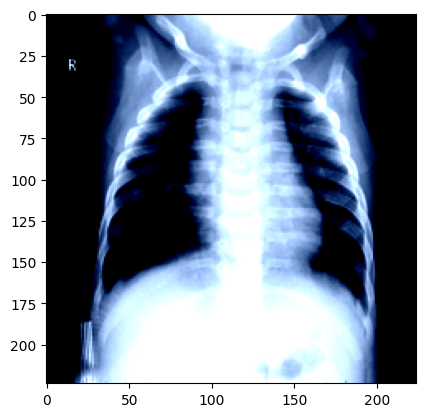

In [ ]:
import matplotlib.pyplot as plt
image,label = train_dataset[10]
plt.imshow(image.permute(1,2,0))

In [ ]:
data_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray"
Train = 'train'
Val = 'val'
Test = 'test'

In [ ]:
from torchvision import transforms as T

def data_transform(phase = None):
    if phase == Train:
        transform = T.Compose([
            T.Resize(size = (224,224)),
            T.RandomRotation(degrees = (-20,+20)),
            T.TrivialAugmentWide(num_magnitude_bins=31),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
        ])
    elif phase == Test or phase == Val:
        transform = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
        ])
    return transform

In [ ]:
import os
from torchvision import datasets
train_dataset = datasets.ImageFolder(os.path.join(data_dir,Train),transform = data_transform(Train))
test_dataset = datasets.ImageFolder(os.path.join(data_dir,Test),transform = data_transform(Test))
val_dataset = datasets.ImageFolder(os.path.join(data_dir,Val),transform = data_transform(Val))

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle = False)
val_loader = DataLoader(val_dataset,batch_size=64,shuffle = True)

In [ ]:
from torchvision.models import swin_s
import torchvision.models as models
model = torch.hub.load('pytorch/vision:v0.10.0', 'densenet121', pretrained=True)
#model = models.efficientnet_b0(pretrained=True)
#model = regnet_y_128gf(weights = RegNet_Y_128GF_Weights.IMAGENET1K_SWAG_E2E_V1)
#model = swin_s(weights = models.Swin_S_Weights.IMAGENET1K_V1)

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 84.4MB/s]


In [ ]:
!pip install torchinfo
from torchinfo import summary
summary(model=model,input_size=(1,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
DenseNet                                 [1, 1000]                 --
├─Sequential: 1-1                        [1, 1024, 7, 7]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
│    └─_DenseBlock: 2-5                  [1, 256, 56, 56]          --
│    │    └─_DenseLayer: 3-1             [1, 32, 56, 56]           45,440
│    │    └─_DenseLayer: 3-2             [1, 32, 56, 56]           49,600
│    │    └─_DenseLayer: 3-3             [1, 32, 56, 56]           53,760
│    │    └─_DenseLayer: 3-4             [1, 32, 56, 56]           57,920
│    │    └─_DenseLayer: 3-5             [1, 32, 56, 56]           62,080
│    │    └─_DenseLayer: 3-6             [1, 32, 56, 56]     

In [ ]:
for parameter in model.features.parameters():
    parameter.requires_grad = False

In [ ]:
import torch.nn as nn
#in_features = model.head.in_features for swin s model
#in_features = model.classifier[1].in_features #for EffcientNet models
#model.head.fc = nn.Sequential( for swin s model
#model.in_features for EffcientNet Models
#model.in_features = nn.Sequential(
    #nn.Linear(in_features, 1024),
   # nn.BatchNorm1d(1024),
    #nn.ReLU(inplace=True),
    #nn.Dropout(0.5),

    #nn.Linear(1024, 256),
    #nn.BatchNorm1d(256),
    #nn.ReLU(inplace=True),
    #nn.Dropout(0.3),

    #nn.Linear(256, 2)  # Binary classification: Pneumonia vs Normal
#)

In [ ]:
!pip install torchinfo
from torchinfo import summary
summary(model=model,input_size=(1,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
DenseNet                                 [1, 1000]                 --
├─Sequential: 1-1                        [1, 1024, 7, 7]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         (9,408)
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         (128)
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
│    └─_DenseBlock: 2-5                  [1, 256, 56, 56]          --
│    │    └─_DenseLayer: 3-1             [1, 32, 56, 56]           (45,440)
│    │    └─_DenseLayer: 3-2             [1, 32, 56, 56]           (49,600)
│    │    └─_DenseLayer: 3-3             [1, 32, 56, 56]           (53,760)
│    │    └─_DenseLayer: 3-4             [1, 32, 56, 56]           (57,920)
│    │    └─_DenseLayer: 3-5             [1, 32, 56, 56]           (62,080)
│    │    └─_DenseLayer: 3-6             [1, 32

In [ ]:
optimizer = optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()
epochs = 5
model.to(device)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
import matplotlib.pyplot as plt
train_losses = []
val_losses = []
accuracies = []
TruePos = 0
TureNeg = 0
FalsePos = 0
FalseNeg = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch + 1}/{epochs} - Training loss: {avg_train_loss:.4f}")
   # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.inference_mode():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            FalsePos += ((predicted == 1) & (labels == 0)).sum().item()
            FalseNeg += ((predicted == 0) & (labels == 1)).sum().item()
            TruePos +=((predicted == 1) & (labels == 1)).sum().item()
            TureNeg = ((predicted == 0) & (labels == 0)).sum().item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_accuracy = correct / total * 100
    accuracies.append(val_accuracy)
    print(f"Epoch {epoch + 1}/{epochs} - Validation loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%")

Epoch 1/5 - Training loss: 1.1316
Epoch 1/5 - Validation loss: 0.4774, Accuracy: 62.50%
Epoch 2/5 - Training loss: 0.3718
Epoch 2/5 - Validation loss: 0.3481, Accuracy: 75.00%
Epoch 3/5 - Training loss: 0.3072
Epoch 3/5 - Validation loss: 0.2551, Accuracy: 93.75%
Epoch 4/5 - Training loss: 0.2663
Epoch 4/5 - Validation loss: 0.2528, Accuracy: 87.50%
Epoch 5/5 - Training loss: 0.2496
Epoch 5/5 - Validation loss: 0.2248, Accuracy: 93.75%


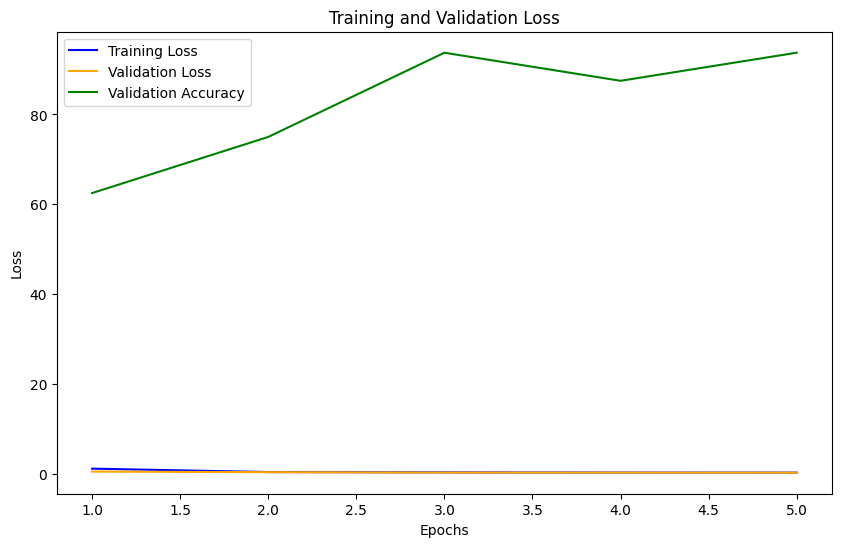

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(10,6))
plt.plot(epochs_range, train_losses, label='Training Loss',color = "blue")
plt.plot(epochs_range, val_losses, label='Validation Loss', color = "orange")
plt.plot(epochs_range, accuracies, label='Validation Accuracy', color = "green")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

<Figure size 800x600 with 0 Axes>

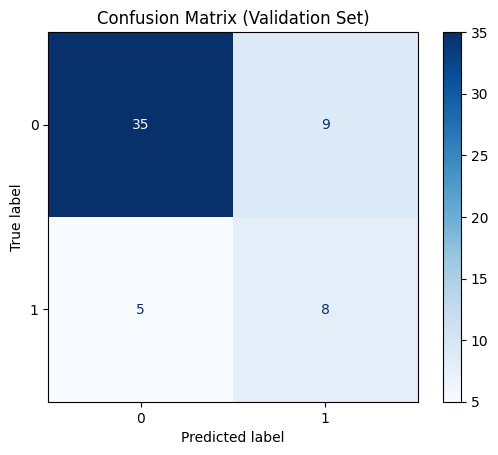

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
all_preds = []
all_labels = []

model.eval()
with torch.inference_mode():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)


plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix (Validation Set)')
plt.grid(False)
plt.show()

model.eval()
TruePos = 0
TureNeg = 0
FalsePos = 0
FalseNeg = 0
test_loss = 0
correct = 0
total = 0
with torch.inference_mode():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        FalsePos += (predicted == 1) & (labels == 0).sum().item()
        FalseNeg += (predicted == 0) & (labels == 1).sum().item()
        TruePos += (predicted == 1) & (labels == 1).sum().item()
        TureNeg = (predicted == 0) & (labels == 0).sum().item()
avg_test_loss = test_loss / len(test_loader)
test_accuracy = correct / total * 100
print(f"Final Test Loss: {avg_test_loss:.4f}, Accuracy: {test_accuracy:.2f}%")

In [ ]:
model.eval()
TruePos = 0
TureNeg = 0
FalsePos = 0
FalseNeg = 0
test_loss = 0
correct = 0
total = 0
with torch.inference_mode():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    loss = loss_fn(outputs, labels)
    test_loss += loss.item()
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    FalsePos += ((predicted == 1) & (labels == 0)).sum().item()
    FalseNeg += ((predicted == 0) & (labels == 1)).sum().item()
    TruePos += ((predicted == 1) & (labels == 1)).sum().item()
    TureNeg = ((predicted == 0) & (labels == 0)).sum().item()
    avg_test_loss = test_loss / len(test_loader)
    test_accuracy = correct / total * 100
print(f"Final Test Loss: {avg_test_loss:.4f}, Accuracy: {test_accuracy:.2f}%")

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=np.array([[TruePos,FalsePos],[FalseNeg,TureNeg]]))


plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix (Test Set)')
plt.grid(False)
plt.show()